# Robust neighbourhood analysis: strip_01

Goal of this notebook: take the annotated cells from `adata_annotated.h5ad` and run a
neighbourhood enrichment analysis that is robust to two free choices: (a) how we
define plasma cells and (b) the size of the spatial neighbourhood (K).

Why we are doing this separately from notebook 02: notebook 02 mixed BANKSY clustering,
annotation, and an exploratory neighbourhood plot in the same flow. That worked for a
first pass but the result depended on one definition of plasma cells (IGHG1 > 0) and one
K (=10), which is fragile. Here we pin down the plasma cell set with stricter criteria
and test the enrichment at K = 5, 10, 20 with permutation-based p-values.

Inputs:
- `outputs/strip_01/adata_annotated.h5ad` (from notebook 02)

Outputs:
- `outputs/strip_01/figures/neighbourhood_K_sensitivity.png`
- `outputs/strip_01/figures/plasma_neighbourhood_robust.png`

Logical flow:
1. Load the annotated AnnData
2. Define three candidate plasma cell sets and compare them
3. Choose the strictest (highest confidence) definition
4. Helper functions for k-NN + permutation enrichment
5. Run at K = 5, 10, 20
6. Compare across K to check the finding is stable
7. Final figure for the prof

## 1. Setup and load

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

ROI = 'strip_01'
OUT = Path(f'../../outputs/{ROI}')
FIG = OUT / 'figures'
FIG.mkdir(parents=True, exist_ok=True)

a = ad.read_h5ad(OUT / 'adata_annotated.h5ad')
print(f'cells          : {a.n_obs:,}')
print(f'genes          : {a.n_vars:,}')
print(f'has labels     : celltype, celltype_refined, is_plasma_cell')
print(f'\ncelltype_refined counts:')
print(a.obs['celltype_refined'].value_counts())

cells          : 7,921
genes          : 21,053
has labels     : celltype, celltype_refined, is_plasma_cell

celltype_refined counts:
fibroblast                 4140
deep_dermal_stromal        2386
keratinocyte_basal_mix     1103
plasma_cell                 142
keratinocyte_suprabasal     106
vascular_mixed               44
Name: celltype_refined, dtype: int64


## 2. Define three candidate plasma cell sets

Different definitions of 'plasma cell' will give different enrichments. We define three,
compare their sizes, and look at how much they overlap. The strictest one becomes our
high-confidence set.

- **A. IGHG1 > 0** (loose, what notebook 02 used)
- **B. Sub-cluster 2** (the 142 cells from sub-clustering deep_dermal_stromal)
- **C. Score-based**: combine IGHG1/2/3/4 + IGKC + JCHAIN into a panel score, take top cells
- **D. Intersection of B and IGHG1 > 0** (strictest, double-confirmed)

In [2]:
# A. IGHG1 > 0 (loose)
ighg1 = a[:, 'IGHG1'].X
ighg1 = ighg1.toarray().flatten() if hasattr(ighg1, 'toarray') else ighg1.flatten()
set_A = ighg1 > 0

# B. From the refined label (subcluster 2 was relabelled to 'plasma_cell')
set_B = a.obs['celltype_refined'].values == 'plasma_cell'

# C. Score-based: composite Ig marker score
ig_panel = [g for g in ['IGHG1','IGHG2','IGHG3','IGHG4','IGKC','JCHAIN'] if g in a.var_names]
sc.tl.score_genes(a, gene_list=ig_panel, score_name='ig_score')
score_threshold = a.obs['ig_score'].quantile(0.975)   # top 2.5% of cells
set_C = (a.obs['ig_score'] > score_threshold).values

# D. Intersection B AND IGHG1 > 0 (strictest)
set_D = set_B & set_A

print(f'A. IGHG1 > 0                   : {set_A.sum():>4} cells')
print(f'B. subcluster 2 (refined label) : {set_B.sum():>4} cells')
print(f'C. Ig panel score top 2.5%     : {set_C.sum():>4} cells  (threshold = {score_threshold:.3f})')
print(f'D. B AND IGHG1 > 0 (strict)    : {set_D.sum():>4} cells')

# overlap matrix
from itertools import combinations
labelled = {'A': set_A, 'B': set_B, 'C': set_C, 'D': set_D}
print('\nPairwise overlap (cells in both):')
for (n1, s1), (n2, s2) in combinations(labelled.items(), 2):
    print(f'  {n1} ∩ {n2}: {int((s1 & s2).sum())}')

A. IGHG1 > 0                   :  204 cells
B. subcluster 2 (refined label) :  142 cells
C. Ig panel score top 2.5%     :  198 cells  (threshold = 0.841)
D. B AND IGHG1 > 0 (strict)    :   93 cells

Pairwise overlap (cells in both):
  A ∩ B: 93
  A ∩ C: 111
  A ∩ D: 93
  B ∩ C: 103
  B ∩ D: 93
  C ∩ D: 82


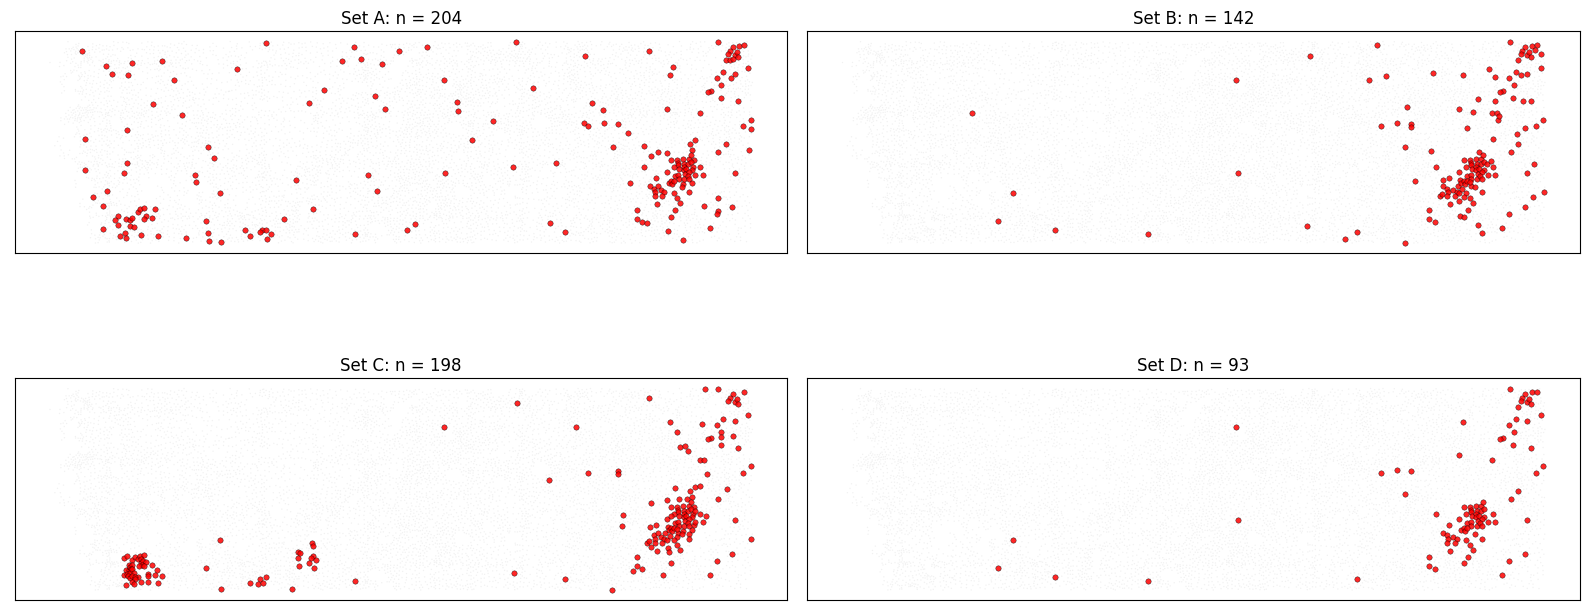

In [3]:
# Visualise the four sets on the strip side-by-side
fig, axes = plt.subplots(2, 2, figsize=(16, 8))
axes = axes.flatten()
xy = a.obsm['spatial']
for ax, (name, mask) in zip(axes, labelled.items()):
    ax.scatter(xy[~mask, 0], xy[~mask, 1], s=1, c='lightgrey', alpha=0.3, edgecolors='none')
    ax.scatter(xy[mask, 0], xy[mask, 1], s=15, c='red', alpha=0.85,
               edgecolors='black', linewidth=0.3)
    ax.invert_yaxis(); ax.set_aspect('equal')
    ax.set_title(f'Set {name}: n = {int(mask.sum())}')
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

**Pick the high-confidence set.** If `D` (intersection) has enough cells (let us say ≥30), use it.
Otherwise fall back to `B` (subcluster 2) or `C` (score-based).

In [4]:
# Add a new label that uses the strictest plasma definition.
# Everything else stays as the refined celltype.
HC_SET = set_D if set_D.sum() >= 30 else set_B
print(f'using high-confidence set of {int(HC_SET.sum())} plasma cells')

labels = a.obs['celltype_refined'].astype(str).copy()
# Reset all originally-labelled plasma cells back to deep_dermal_stromal
labels[labels == 'plasma_cell'] = 'deep_dermal_stromal'
# Now flag only the high-confidence ones as plasma_cell
labels[HC_SET] = 'plasma_cell'
a.obs['celltype_hc'] = pd.Categorical(labels)

print('\ncelltype_hc counts:')
print(a.obs['celltype_hc'].value_counts())

using high-confidence set of 93 plasma cells

celltype_hc counts:
fibroblast                 4140
deep_dermal_stromal        2435
keratinocyte_basal_mix     1103
keratinocyte_suprabasal     106
plasma_cell                  93
vascular_mixed               44
Name: celltype_hc, dtype: int64


## 3. Helper: permutation-based neighbourhood enrichment

For a given K, we:
1. Build the k-nearest-neighbour graph on chip coordinates
2. Compute the observed neighbour composition for every focal type
3. Shuffle the cell-type labels `n_perm` times; recompute composition each time
4. Per pair (focal A, neighbour B): observed value vs the null distribution
   → z-score and one-sided p-value (how often shuffled >= observed)

This is the same logic as squidpy's nhood_enrichment, written explicitly so we can see
every step.

In [5]:
def neighbourhood_enrichment(positions, labels, K=10, n_perm=500, seed=0, verbose=True):
    """Return observed, null mean, z-score and p-value matrices indexed by cell type."""
    rng = np.random.default_rng(seed)
    labels = np.asarray(labels)

    # Build k-NN graph once
    nn = NearestNeighbors(n_neighbors=K + 1).fit(positions)
    _, idx = nn.kneighbors(positions)
    idx = idx[:, 1:]                                       # drop self

    types = np.unique(labels)
    nT = len(types)
    t_to_i = {t: i for i, t in enumerate(types)}

    def composition(lbls):
        nb = lbls[idx]                                     # (n_cells, K)
        comp = np.zeros((nT, nT))
        for i, a in enumerate(types):
            focal = lbls == a
            if focal.sum() == 0: continue
            for j, b in enumerate(types):
                comp[i, j] = (nb[focal] == b).mean()
        return comp

    if verbose: print(f'  K = {K}: computing observed...')
    observed = composition(labels)

    if verbose: print(f'  K = {K}: running {n_perm} permutations...')
    null = np.zeros((n_perm, nT, nT))
    for p in range(n_perm):
        shuf = rng.permutation(labels)
        null[p] = composition(shuf)

    null_mean = null.mean(axis=0)
    null_std  = null.std(axis=0) + 1e-9
    zscore = (observed - null_mean) / null_std
    pval = ((null >= observed[None, :, :]).sum(axis=0) + 1) / (n_perm + 1)

    return dict(
        types=types,
        observed=pd.DataFrame(observed, index=types, columns=types),
        null_mean=pd.DataFrame(null_mean, index=types, columns=types),
        zscore=pd.DataFrame(zscore, index=types, columns=types),
        pval=pd.DataFrame(pval, index=types, columns=types),
    )

## 4. Run at K = 5, 10, 20

In [6]:
positions = a.obsm['spatial']
labels_hc = a.obs['celltype_hc'].astype(str).to_numpy()

results = {}
for K in [5, 10, 20]:
    print(f'\n=== K = {K} ===')
    results[K] = neighbourhood_enrichment(positions, labels_hc, K=K, n_perm=500, seed=0)


=== K = 5 ===
  K = 5: computing observed...
  K = 5: running 500 permutations...

=== K = 10 ===
  K = 10: computing observed...
  K = 10: running 500 permutations...

=== K = 20 ===
  K = 20: computing observed...
  K = 20: running 500 permutations...


## 5. K sensitivity for plasma cell enrichment

Compare the plasma cell row across the three K values. If the same neighbours come up
enriched at all three K, the result is robust. If it only shows up at one K, the
finding is fragile.

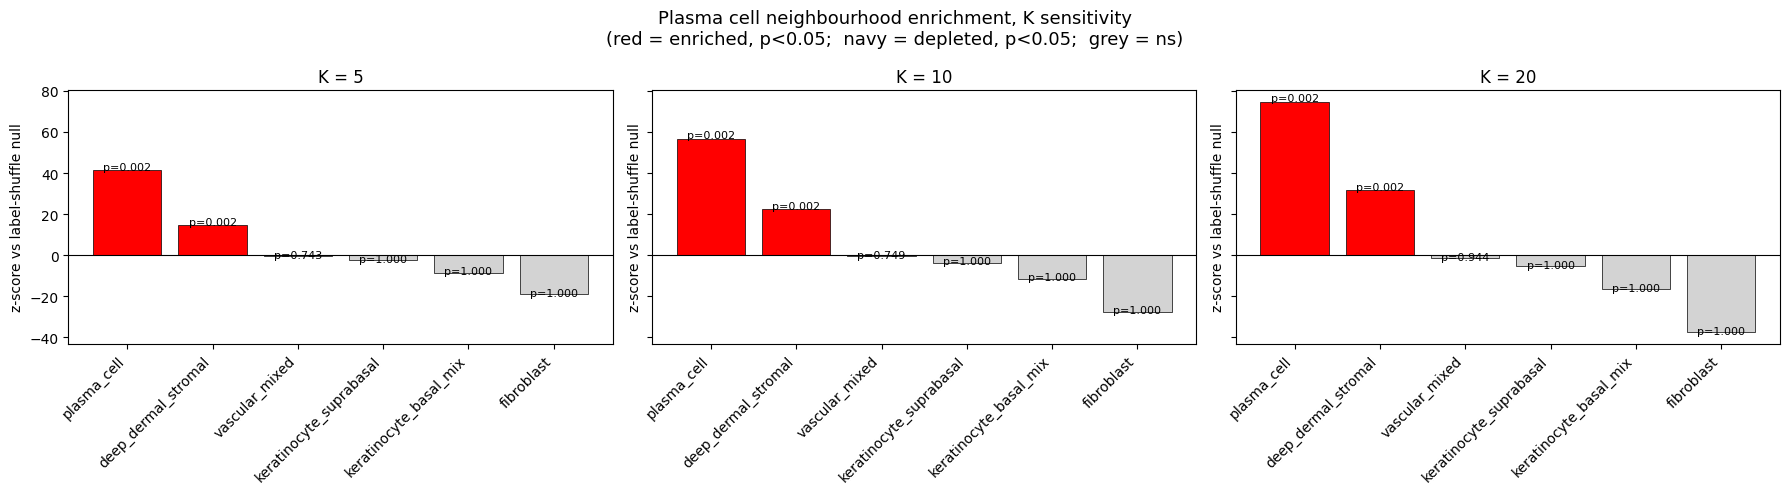

In [7]:
ALPHA = 0.05   # significance threshold

types = results[5]['types']
n_types = len(types)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, K in zip(axes, [5, 10, 20]):
    z = results[K]['zscore'].loc['plasma_cell']
    p = results[K]['pval'].loc['plasma_cell']
    order = z.sort_values(ascending=False).index
    z_o, p_o = z[order], p[order]

    colors = ['red' if (zv > 0 and pv < ALPHA)
              else 'navy' if (zv < 0 and pv < ALPHA)
              else 'lightgrey' for zv, pv in zip(z_o, p_o)]
    ax.bar(range(len(z_o)), z_o.values, color=colors, edgecolor='black', linewidth=0.5)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(range(len(z_o)))
    ax.set_xticklabels(z_o.index, rotation=45, ha='right')
    ax.set_title(f'K = {K}')
    ax.set_ylabel('z-score vs label-shuffle null')
    # annotate p-values
    for i, (zv, pv) in enumerate(zip(z_o, p_o)):
        ax.text(i, zv + (0.3 if zv >= 0 else -0.8),
                f'p={pv:.3f}', ha='center', fontsize=8)

fig.suptitle('Plasma cell neighbourhood enrichment, K sensitivity\n'
             '(red = enriched, p<0.05;  navy = depleted, p<0.05;  grey = ns)', fontsize=13)
plt.tight_layout()
plt.savefig(FIG / 'neighbourhood_K_sensitivity.png', dpi=140, bbox_inches='tight')
plt.show()

## 6. Final figure for the prof

Two-panel summary using K = 10 (the middle, most stable choice):
- Heatmap of z-scores for all cell-type pairs (only significant cells coloured)
- Bar chart of plasma cell enrichment with p-values

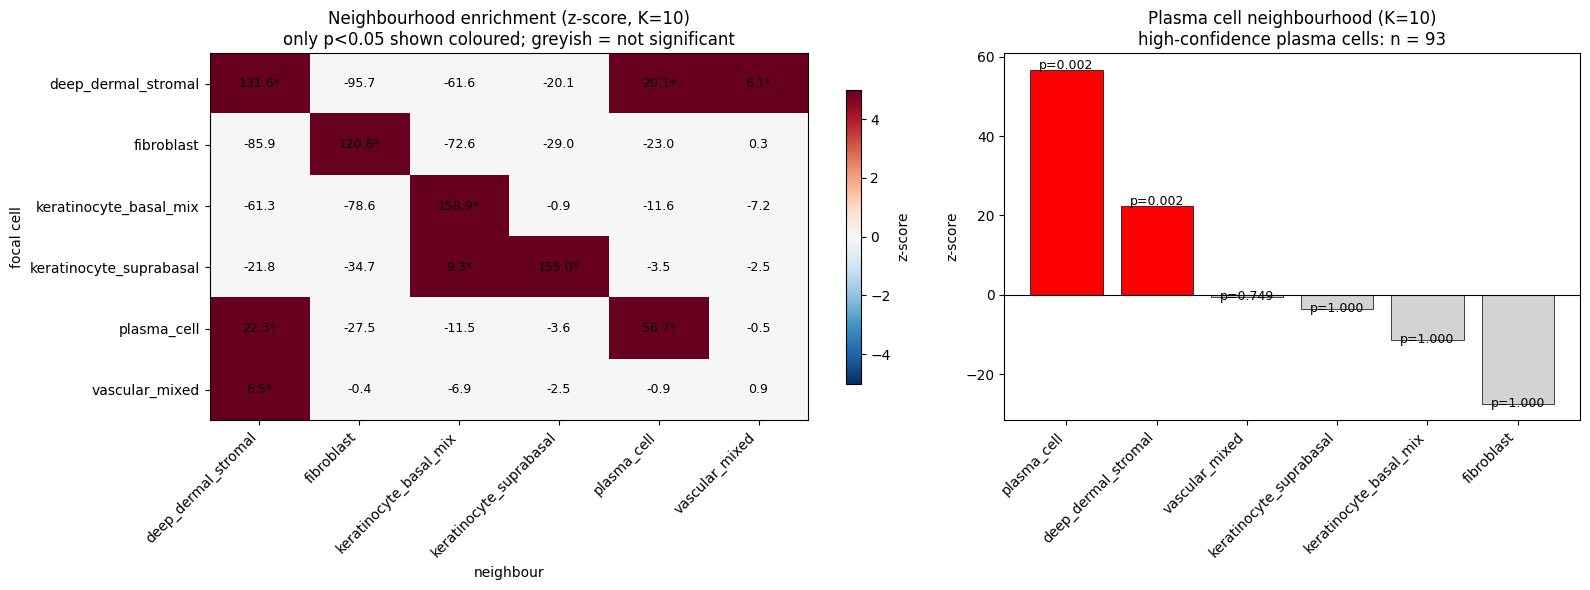

In [8]:
K_MAIN = 10
z = results[K_MAIN]['zscore']
p = results[K_MAIN]['pval']

# Mask non-significant cells in the heatmap
z_masked = z.where(p < ALPHA, 0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                          gridspec_kw={'width_ratios': [1.3, 1]})

# Heatmap
im = axes[0].imshow(z_masked.values, cmap='RdBu_r', aspect='auto', vmin=-5, vmax=5)
axes[0].set_xticks(range(n_types)); axes[0].set_xticklabels(z.columns, rotation=45, ha='right')
axes[0].set_yticks(range(n_types)); axes[0].set_yticklabels(z.index)
axes[0].set_title(f'Neighbourhood enrichment (z-score, K={K_MAIN})\n'
                  f'only p<{ALPHA} shown coloured; greyish = not significant')
axes[0].set_xlabel('neighbour'); axes[0].set_ylabel('focal cell')
for i in range(n_types):
    for j in range(n_types):
        val = z.values[i, j]
        sig = '*' if p.values[i, j] < ALPHA else ''
        axes[0].text(j, i, f'{val:.1f}{sig}', ha='center', va='center',
                     fontsize=9, color='black')
plt.colorbar(im, ax=axes[0], shrink=0.8, label='z-score')

# Plasma cell bar chart
z_p = z.loc['plasma_cell']
p_p = p.loc['plasma_cell']
order = z_p.sort_values(ascending=False).index
z_po, p_po = z_p[order], p_p[order]
colors = ['red' if (zv > 0 and pv < ALPHA)
          else 'navy' if (zv < 0 and pv < ALPHA)
          else 'lightgrey' for zv, pv in zip(z_po, p_po)]
axes[1].bar(range(len(z_po)), z_po.values, color=colors, edgecolor='black', linewidth=0.5)
axes[1].axhline(0, color='black', lw=0.8)
axes[1].set_xticks(range(len(z_po)))
axes[1].set_xticklabels(z_po.index, rotation=45, ha='right')
axes[1].set_ylabel('z-score')
axes[1].set_title(f'Plasma cell neighbourhood (K={K_MAIN})\n'
                  f'high-confidence plasma cells: n = {int(HC_SET.sum())}')
for i, (zv, pv) in enumerate(zip(z_po, p_po)):
    axes[1].text(i, zv + (0.3 if zv >= 0 else -0.8), f'p={pv:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIG / 'plasma_neighbourhood_robust.png', dpi=140, bbox_inches='tight')
plt.show()

markers found in data (12): ['IGHG1', 'IGHG2', 'IGHG3', 'IGHG4', 'IGKC', 'IGLC2', 'IGLC3', 'JCHAIN', 'MZB1', 'XBP1', 'SDC1', 'CD79A']
markers MISSING from data: ['IGLC1']

Fraction of cells expressing each marker (per definition):
        A (IGHG1>0, n=204)  B (subcluster 2, n=142)  \
IGHG1                1.000                    0.655   
IGHG2                0.054                    0.077   
IGHG3                0.260                    0.303   
IGHG4                0.564                    0.725   
IGKC                 0.358                    0.444   
IGLC2                0.054                    0.042   
IGLC3                0.142                    0.099   
JCHAIN               0.039                    0.000   
MZB1                 0.000                    0.000   
XBP1                 0.098                    0.085   
SDC1                 0.353                    0.197   
CD79A                0.005                    0.014   

        C (Ig score top 2.5%, n=198)  D (B AND IGHG1>

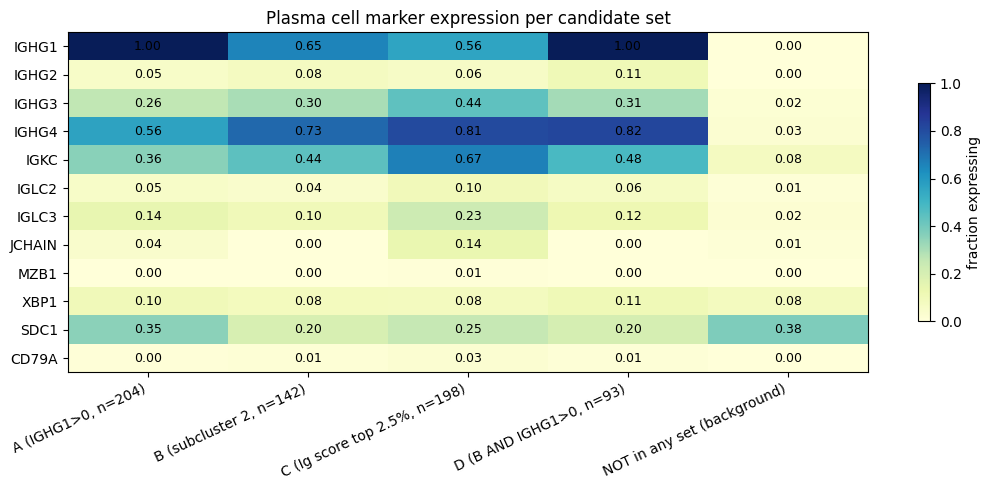

In [9]:
# Expanded plasma cell marker panel
# Add: SDC1 (CD138, classic plasma cell), CD79A, IGLC1/2/3
panel = ['IGHG1', 'IGHG2', 'IGHG3', 'IGHG4',
         'IGKC', 'IGLC1', 'IGLC2', 'IGLC3',
         'JCHAIN', 'MZB1', 'XBP1', 'SDC1', 'CD79A']
panel_in = [g for g in panel if g in a.var_names]
panel_missing = [g for g in panel if g not in a.var_names]
print(f'markers found in data ({len(panel_in)}): {panel_in}')
print(f'markers MISSING from data: {panel_missing}\n')

# For each candidate set, compute fraction of cells expressing each marker
def fraction_expressing(adata, mask, genes):
    out = {}
    for g in genes:
        x = adata[:, g].X
        x = x.toarray().flatten() if hasattr(x, 'toarray') else x.flatten()
        out[g] = float((x[mask] > 0).mean()) if mask.sum() > 0 else 0.0
    return out

sets_dict = {'A (IGHG1>0, n=204)': set_A,
             'B (subcluster 2, n=142)': set_B,
             'C (Ig score top 2.5%, n=198)': set_C,
             'D (B AND IGHG1>0, n=93)': set_D,
             'NOT in any set (background)': ~(set_A | set_B | set_C | set_D)}

frac_table = pd.DataFrame({name: fraction_expressing(a, mask, panel_in)
                           for name, mask in sets_dict.items()})
print('Fraction of cells expressing each marker (per definition):')
print(frac_table.round(3))

# Per-set "score": how many markers does each cell express?
expr_matrix = np.zeros((a.n_obs, len(panel_in)))
for j, g in enumerate(panel_in):
    x = a[:, g].X
    x = x.toarray().flatten() if hasattr(x, 'toarray') else x.flatten()
    expr_matrix[:, j] = (x > 0).astype(int)
markers_expressed = expr_matrix.sum(axis=1)
a.obs['n_plasma_markers'] = markers_expressed

print(f'\nDistribution: how many plasma cell markers per cell')
for name, mask in sets_dict.items():
    vals = markers_expressed[mask]
    if len(vals) == 0: continue
    print(f'  {name:<35} median = {int(np.median(vals))}  '
          f'mean = {vals.mean():.1f}  max = {int(vals.max())}')

# Heatmap of fractions
fig, ax = plt.subplots(figsize=(11, 5))
im = ax.imshow(frac_table.values, cmap='YlGnBu', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(frac_table.columns)))
ax.set_xticklabels(frac_table.columns, rotation=25, ha='right')
ax.set_yticks(range(len(frac_table.index)))
ax.set_yticklabels(frac_table.index)
for i in range(len(frac_table.index)):
    for j in range(len(frac_table.columns)):
        ax.text(j, i, f'{frac_table.values[i, j]:.2f}', ha='center', va='center',
                color='black', fontsize=9)
plt.colorbar(im, ax=ax, shrink=0.7, label='fraction expressing')
ax.set_title('Plasma cell marker expression per candidate set')
plt.tight_layout()
plt.savefig(FIG / 'plasma_marker_validation.png', dpi=140, bbox_inches='tight')
plt.show()

In [10]:
# Block 2: upgraded neighbourhood enrichment with raw fractions,
# observed/expected, two-sided p-values, and BH/FDR correction.
# No output expected -- this just defines helper functions used by Block 3.

def benjamini_hochberg(pvals):
    """BH/FDR correction. Input: any-shape array of p-values. Output: same shape, adjusted."""
    p = np.asarray(pvals)
    shape = p.shape
    flat = p.flatten()
    n = len(flat)
    order = np.argsort(flat)
    ranks = np.arange(1, n + 1)
    sorted_p = flat[order]
    raw_adj = sorted_p * n / ranks
    # enforce monotonicity from largest -> smallest
    adj_sorted = np.minimum.accumulate(raw_adj[::-1])[::-1]
    adj_sorted = np.minimum(adj_sorted, 1.0)
    adj = np.empty(n)
    adj[order] = adj_sorted
    return adj.reshape(shape)


def neighbourhood_enrichment_v2(positions, labels, K=10, n_perm=500, seed=0,
                                 alternative='two-sided'):
    """Robust neighbourhood enrichment with permutation test + FDR.

    Returns dict with:
      observed_fraction  mean fraction of K neighbours of each type per focal type
      expected_fraction  background frequency of each type (= chance)
      log2_ratio         log2(observed / expected) -- direct effect size
      zscore             (observed - null_mean) / null_std
      pval               permutation p-value at the requested alternative
      qval               BH/FDR adjusted p-values across all cell-type pairs
    """
    rng = np.random.default_rng(seed)
    labels = np.asarray(labels)

    # k-nearest-neighbour graph in chip coordinates
    nn = NearestNeighbors(n_neighbors=K + 1).fit(positions)
    _, idx = nn.kneighbors(positions)
    idx = idx[:, 1:]                                 # drop self

    types = np.unique(labels)
    nT = len(types)

    def composition(lbls):
        nb = lbls[idx]                               # (n_cells, K)
        comp = np.zeros((nT, nT))
        for i, a_t in enumerate(types):
            focal = lbls == a_t
            if focal.sum() == 0:
                continue
            for j, b_t in enumerate(types):
                comp[i, j] = (nb[focal] == b_t).mean()
        return comp

    # observed and expected
    observed = composition(labels)
    expected = np.tile(
        pd.Series(labels).value_counts(normalize=True).reindex(types).fillna(0).values,
        (nT, 1)
    )

    # permutation null distribution
    null = np.zeros((n_perm, nT, nT))
    for p in range(n_perm):
        shuf = rng.permutation(labels)
        null[p] = composition(shuf)

    null_mean = null.mean(axis=0)
    null_std  = null.std(axis=0) + 1e-9
    zscore = (observed - null_mean) / null_std

    # p-value depending on test direction
    if alternative == 'greater':
        pval = ((null >= observed[None]).sum(axis=0) + 1) / (n_perm + 1)
    elif alternative == 'less':
        pval = ((null <= observed[None]).sum(axis=0) + 1) / (n_perm + 1)
    elif alternative == 'two-sided':
        p_hi = ((null >= observed[None]).sum(axis=0) + 1) / (n_perm + 1)
        p_lo = ((null <= observed[None]).sum(axis=0) + 1) / (n_perm + 1)
        pval = np.minimum(2 * np.minimum(p_hi, p_lo), 1.0)
    else:
        raise ValueError("alternative must be 'greater', 'less', or 'two-sided'")

    qval = benjamini_hochberg(pval)

    return dict(
        types=types,
        observed_fraction=pd.DataFrame(observed,  index=types, columns=types),
        expected_fraction=pd.DataFrame(expected,  index=types, columns=types),
        log2_ratio=pd.DataFrame(np.log2((observed + 1e-3) / (expected + 1e-3)),
                                index=types, columns=types),
        zscore=pd.DataFrame(zscore,   index=types, columns=types),
        pval=pd.DataFrame(pval,    index=types, columns=types),
        qval=pd.DataFrame(qval,    index=types, columns=types),
    )

print('Block 2 ready: benjamini_hochberg + neighbourhood_enrichment_v2 defined.')

Block 2 ready: benjamini_hochberg + neighbourhood_enrichment_v2 defined.


In [11]:
# Quick CD38 check (commonly used plasma cell marker, missed earlier)
if 'CD38' in a.var_names:
    cd38 = a[:, 'CD38'].X
    cd38 = cd38.toarray().flatten() if hasattr(cd38, 'toarray') else cd38.flatten()
    for name, mask in sets_dict.items():
        if mask.sum() == 0: continue
        print(f'{name:<35} CD38+ fraction = {float((cd38[mask] > 0).mean()):.3f}')
else:
    print('CD38 not in the data')

A (IGHG1>0, n=204)                  CD38+ fraction = 0.005
B (subcluster 2, n=142)             CD38+ fraction = 0.000
C (Ig score top 2.5%, n=198)        CD38+ fraction = 0.000
D (B AND IGHG1>0, n=93)             CD38+ fraction = 0.000
NOT in any set (background)         CD38+ fraction = 0.001


In [12]:
# Block 3: run enrichment for both plasma cell definitions, with honest naming.

PLASMA_LABEL = 'IgG_producing'   # conservative: matches what the markers actually show
positions = a.obsm['spatial']

def run_with_plasma_set(plasma_mask, name):
    """Rebuild celltype labels using the given antibody-secreting cell set."""
    lbls = a.obs['celltype_refined'].astype(str).copy()
    # Reset any old 'plasma_cell' label so it doesn't double-count
    lbls[lbls == 'plasma_cell'] = 'deep_dermal_stromal'
    lbls[plasma_mask] = PLASMA_LABEL
    print(f'\n=== {name}: {int(plasma_mask.sum())} {PLASMA_LABEL} cells ===')
    return neighbourhood_enrichment_v2(
        positions, lbls.values, K=10, n_perm=500, seed=0, alternative='two-sided'
    )

res_A = run_with_plasma_set(set_A, 'Set A (loose, IGHG1>0)')
res_D = run_with_plasma_set(set_D, 'Set D (strict, B AND IGHG1>0)')


def show_plasma_row(res, name):
    print(f'\n--- {name}  --  {PLASMA_LABEL} neighbour stats (K=10) ---')
    row = pd.DataFrame({
        'observed_frac':  res['observed_fraction'].loc[PLASMA_LABEL],
        'expected_frac':  res['expected_fraction'].loc[PLASMA_LABEL],
        'log2_ratio':     res['log2_ratio'].loc[PLASMA_LABEL],
        'zscore':         res['zscore'].loc[PLASMA_LABEL],
        'pval_2sided':    res['pval'].loc[PLASMA_LABEL],
        'qval_BH_FDR':    res['qval'].loc[PLASMA_LABEL],
    }).sort_values('zscore', ascending=False)
    print(row.round(3))

show_plasma_row(res_A, 'Set A (loose, n=204)')
show_plasma_row(res_D, 'Set D (strict, n=93)')


=== Set A (loose, IGHG1>0): 204 IgG_producing cells ===

=== Set D (strict, B AND IGHG1>0): 93 IgG_producing cells ===

--- Set A (loose, n=204)  --  IgG_producing neighbour stats (K=10) ---
                         observed_frac  expected_frac  log2_ratio  zscore  \
IgG_producing                    0.186          0.026       2.807  36.233   
deep_dermal_stromal              0.403          0.304       0.407  10.073   
keratinocyte_basal_mix           0.154          0.135       0.192   2.605   
vascular_mixed                   0.004          0.005      -0.191  -0.510   
keratinocyte_suprabasal          0.003          0.013      -1.855  -4.394   
fibroblast                       0.249          0.517      -1.051 -24.424   

                         pval_2sided  qval_BH_FDR  
IgG_producing                  0.004        0.005  
deep_dermal_stromal            0.004        0.005  
keratinocyte_basal_mix         0.004        0.005  
vascular_mixed                 0.758        0.780  
keratino

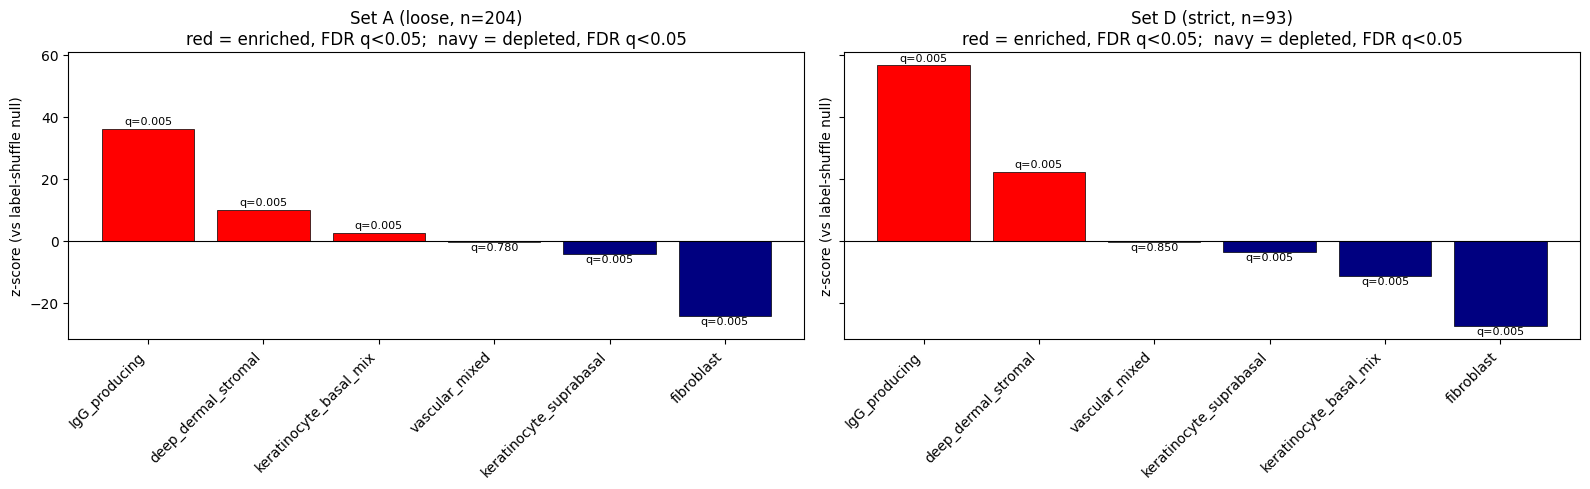

In [13]:
# Block 4: visual comparison of Set A vs Set D, with FDR q-values marked.

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, res, name in [(axes[0], res_A, 'Set A (loose, n=204)'),
                       (axes[1], res_D, 'Set D (strict, n=93)')]:
    z = res['zscore'].loc[PLASMA_LABEL]
    q = res['qval'].loc[PLASMA_LABEL]
    order = z.sort_values(ascending=False).index
    z_o, q_o = z[order], q[order]
    colors = ['red'  if (zv > 0 and qv < 0.05)
              else 'navy' if (zv < 0 and qv < 0.05)
              else 'lightgrey' for zv, qv in zip(z_o, q_o)]
    ax.bar(range(len(z_o)), z_o.values, color=colors, edgecolor='black', linewidth=0.5)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(range(len(z_o)))
    ax.set_xticklabels(z_o.index, rotation=45, ha='right')
    ax.set_ylabel('z-score (vs label-shuffle null)')
    ax.set_title(f'{name}\nred = enriched, FDR q<0.05;  navy = depleted, FDR q<0.05')
    for i, (zv, qv) in enumerate(zip(z_o, q_o)):
        ax.text(i, zv + (1.5 if zv >= 0 else -2.5),
                f'q={qv:.3f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig(FIG / 'IgG_neighbourhood_A_vs_D.png', dpi=140, bbox_inches='tight')
plt.show()